## Importing Libraries

In [29]:


import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [30]:
print(tf.config.list_physical_devices('GPU'))

[]


#### Dataset Link: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

## Data Preprocessing

### Training Image Preprocessing

In [31]:
training_set = tf.keras.utils.image_dataset_from_directory(
    r"C:\essat\projet ia\detectation de maladie\dataset\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train",  # Correctly formatted path
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 70295 files belonging to 38 classes.


### Validation Image Preprocessing

In [32]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    r"C:\essat\projet ia\detectation de maladie\dataset\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\valid",  # Correctly formatted path
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [33]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [34]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[110.75  94.75 104.75]
   [ 99.25  83.25  93.25]
   [102.    86.    96.  ]
   ...
   [114.75 101.75 110.75]
   [119.5  106.5  115.5 ]
   [111.25  98.25 107.25]]

  [[118.5  102.5  112.5 ]
   [122.5  106.5  116.5 ]
   [120.75 104.75 114.75]
   ...
   [ 96.25  83.25  92.25]
   [125.25 112.25 121.25]
   [106.    93.   102.  ]]

  [[107.25  91.25 101.25]
   [105.5   89.5   99.5 ]
   [118.   102.   112.  ]
   ...
   [113.5  100.5  109.5 ]
   [112.    99.   108.  ]
   [110.75  97.75 106.75]]

  ...

  [[151.75 140.75 148.75]
   [161.5  150.5  158.5 ]
   [160.75 149.75 157.75]
   ...
   [175.   166.   171.  ]
   [177.   168.   173.  ]
   [188.25 179.25 184.25]]

  [[158.5  147.5  155.5 ]
   [154.   143.   151.  ]
   [159.   148.   156.  ]
   ...
   [179.5  170.5  175.5 ]
   [182.5  173.5  178.5 ]
   [172.   163.   168.  ]]

  [[160.5  149.5  157.5 ]
   [150.5  139.5  147.5 ]
   [158.5  147.5  155.5 ]
   ...
   [172.75 163.75 168.75]
   [172.75 163.75 168.75]
   [175.25 166.25 17

### To avoid Overshooting
1. Choose small learning rate default 0.001 we are taking 0.0001
2. There may be chance of Underfitting, so increase number of neuron
3. Add more Convolution layer to extract more feature from images there may be possibilty that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

## Building Model

In [35]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [36]:
model = Sequential()

In [37]:
## Building Convolution Layer

In [38]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [39]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [40]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [41]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [42]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [43]:
model.add(Dropout(0.25)) # To avoid Overfitting

In [44]:
model.add(Flatten())

In [45]:
model.add(Dense(units=1500,activation='relu'))

In [46]:
model.add(Dropout(0.4))

In [47]:
#Output Layer
model.add(Dense(units=38,activation='softmax'))

### Compiling Model

In [48]:
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [49]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_10 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 conv2d_11 (Conv2D)          (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_12 (Conv2D)          (None, 63, 63, 64)        18496     
                                                                 
 conv2d_13 (Conv2D)          (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                  

### Model Training

In [50]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 [==============================] - 1540s 699ms/step - loss: 1.3593 - accuracy: 0.6010 - val_loss: 0.5018 - val_accuracy: 0.8452
Epoch 2/10
2197/2197 [==============================] - 1844s 839ms/step - loss: 0.4445 - accuracy: 0.8584 - val_loss: 0.3303 - val_accuracy: 0.8948
Epoch 3/10
2197/2197 [==============================] - 1828s 832ms/step - loss: 0.2650 - accuracy: 0.9148 - val_loss: 0.1910 - val_accuracy: 0.9379
Epoch 4/10
2197/2197 [==============================] - 1806s 822ms/step - loss: 0.1815 - accuracy: 0.9410 - val_loss: 0.1778 - val_accuracy: 0.9408
Epoch 5/10
2197/2197 [==============================] - 1816s 827ms/step - loss: 0.1309 - accuracy: 0.9570 - val_loss: 0.1881 - val_accuracy: 0.9425
Epoch 6/10
2197/2197 [==============================] - 1828s 832ms/step - loss: 0.1052 - accuracy: 0.9653 - val_loss: 0.1445 - val_accuracy: 0.9515
Epoch 7/10
2197/2197 [==============================] - 1845s 840ms/step - loss: 0.0883 - accuracy: 0.9717

## Model Evaluation

In [51]:
#Model Evaluation on Training set
train_loss,train_acc = model.evaluate(training_set)

2197/2197 [==============================] - 476s 217ms/step - loss: 0.0509 - accuracy: 0.9832


In [52]:
print(train_loss,train_acc)

0.050884511321783066 0.983156681060791


In [53]:
#Model on Validation set
val_loss,val_acc = model.evaluate(validation_set)

550/550 [==============================] - 115s 209ms/step - loss: 0.1458 - accuracy: 0.9567


In [54]:
print(val_loss,val_acc)

0.14576472342014313 0.9567493796348572


### Saving Model

In [55]:
model.save("trained_model.keras")

In [56]:
training_history.history

{'loss': [1.3592536449432373,
  0.4444866180419922,
  0.264972448348999,
  0.1814795732498169,
  0.13089865446090698,
  0.10518907010555267,
  0.08833108097314835,
  0.07165057957172394,
  0.06332225352525711,
  0.054937828332185745],
 'accuracy': [0.6009531021118164,
  0.858382523059845,
  0.9147592186927795,
  0.941034197807312,
  0.9570239782333374,
  0.9653460383415222,
  0.9716907143592834,
  0.9766982197761536,
  0.9799559116363525,
  0.9821324348449707],
 'val_loss': [0.5018191933631897,
  0.3303191363811493,
  0.19097496569156647,
  0.1777975708246231,
  0.18806780874729156,
  0.1445157676935196,
  0.10863092541694641,
  0.0896143987774849,
  0.16675123572349548,
  0.14576487243175507],
 'val_accuracy': [0.8452082872390747,
  0.8948326706886292,
  0.9378556609153748,
  0.9407580494880676,
  0.9424653053283691,
  0.9514568448066711,
  0.9661393165588379,
  0.9714318513870239,
  0.9492943286895752,
  0.9567493796348572]}

In [57]:
#Recording History in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

In [ ]:
training_history.history['val_accuracy']

[0.8452082872390747,
 0.8948326706886292,
 0.9378556609153748,
 0.9407580494880676,
 0.9424653053283691,
 0.9514568448066711,
 0.9661393165588379,
 0.9714318513870239,
 0.9492943286895752,
 0.9567493796348572]

: 

### Accuracy Visualization

In [ ]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

### Some other metrics for model evaluation

In [ ]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [ ]:
test_set = tf.keras.utils.image_dataset_from_directory(
    r'C:\Users\mohamed\Desktop\IA\dataset\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [ ]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

550/550 [==============================] - 17s 30ms/step


(array([[9.99989033e-01, 1.83143687e-08, 2.66027866e-10, ...,
         2.20027616e-14, 6.33284352e-15, 1.52042409e-12],
        [1.00000000e+00, 2.10355591e-08, 3.08930481e-09, ...,
         4.95137411e-18, 1.68481003e-14, 2.95477415e-14],
        [1.00000000e+00, 5.02207694e-12, 2.54622517e-12, ...,
         5.97623765e-17, 2.14297509e-16, 7.14311423e-14],
        ...,
        [2.29877922e-11, 1.05256009e-15, 3.38500894e-11, ...,
         6.87252555e-12, 5.01774288e-14, 9.99761403e-01],
        [2.51774851e-10, 3.27100441e-14, 1.32275024e-10, ...,
         4.92334576e-11, 3.22732943e-12, 9.99999762e-01],
        [3.99146292e-13, 2.51915412e-15, 4.49023116e-13, ...,
         1.18191385e-11, 4.53657778e-10, 9.99992013e-01]], dtype=float32),
 (17572, 38))

In [ ]:
predicted_categories = tf.argmax(y_pred,axis=1)

In [ ]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [ ]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [ ]:
Y_true = tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

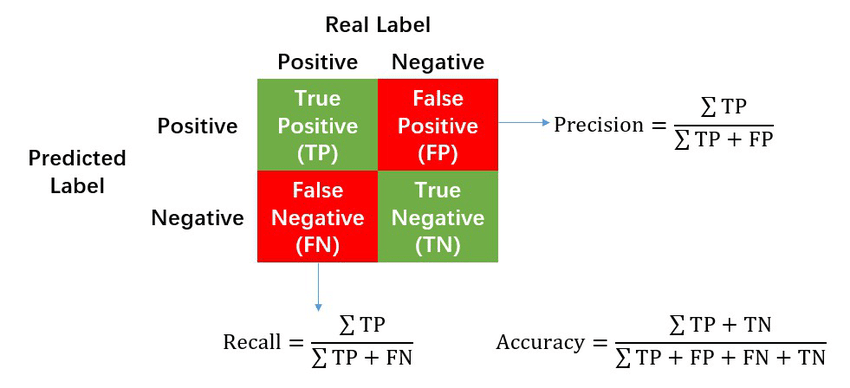

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

In [ ]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.98      0.98       504
                                 Apple___Black_rot       1.00      0.98      0.99       497
                          Apple___Cedar_apple_rust       0.94      0.96      0.95       440
                                   Apple___healthy       0.98      0.96      0.97       502
                               Blueberry___healthy       0.93      1.00      0.96       454
          Cherry_(including_sour)___Powdery_mildew       0.98      0.99      0.98       421
                 Cherry_(including_sour)___healthy       0.99      0.98      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.92      0.93       410
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       477
               Corn_(maize)___Northern_Leaf_Blight       0.93      0.97      0.

In [ ]:
cm = confusion_matrix(Y_true,predicted_categories)
cm

array([[496,   0,   0, ...,   0,   0,   0],
       [  3, 485,   0, ...,   0,   0,   0],
       [  0,   0, 424, ...,   0,   0,   1],
       ...,
       [  0,   0,   1, ..., 483,   0,   0],
       [  0,   0,   0, ...,   0, 432,   0],
       [  0,   0,   0, ...,   0,   0, 461]], dtype=int64)

### Confusion Matrix Visualization

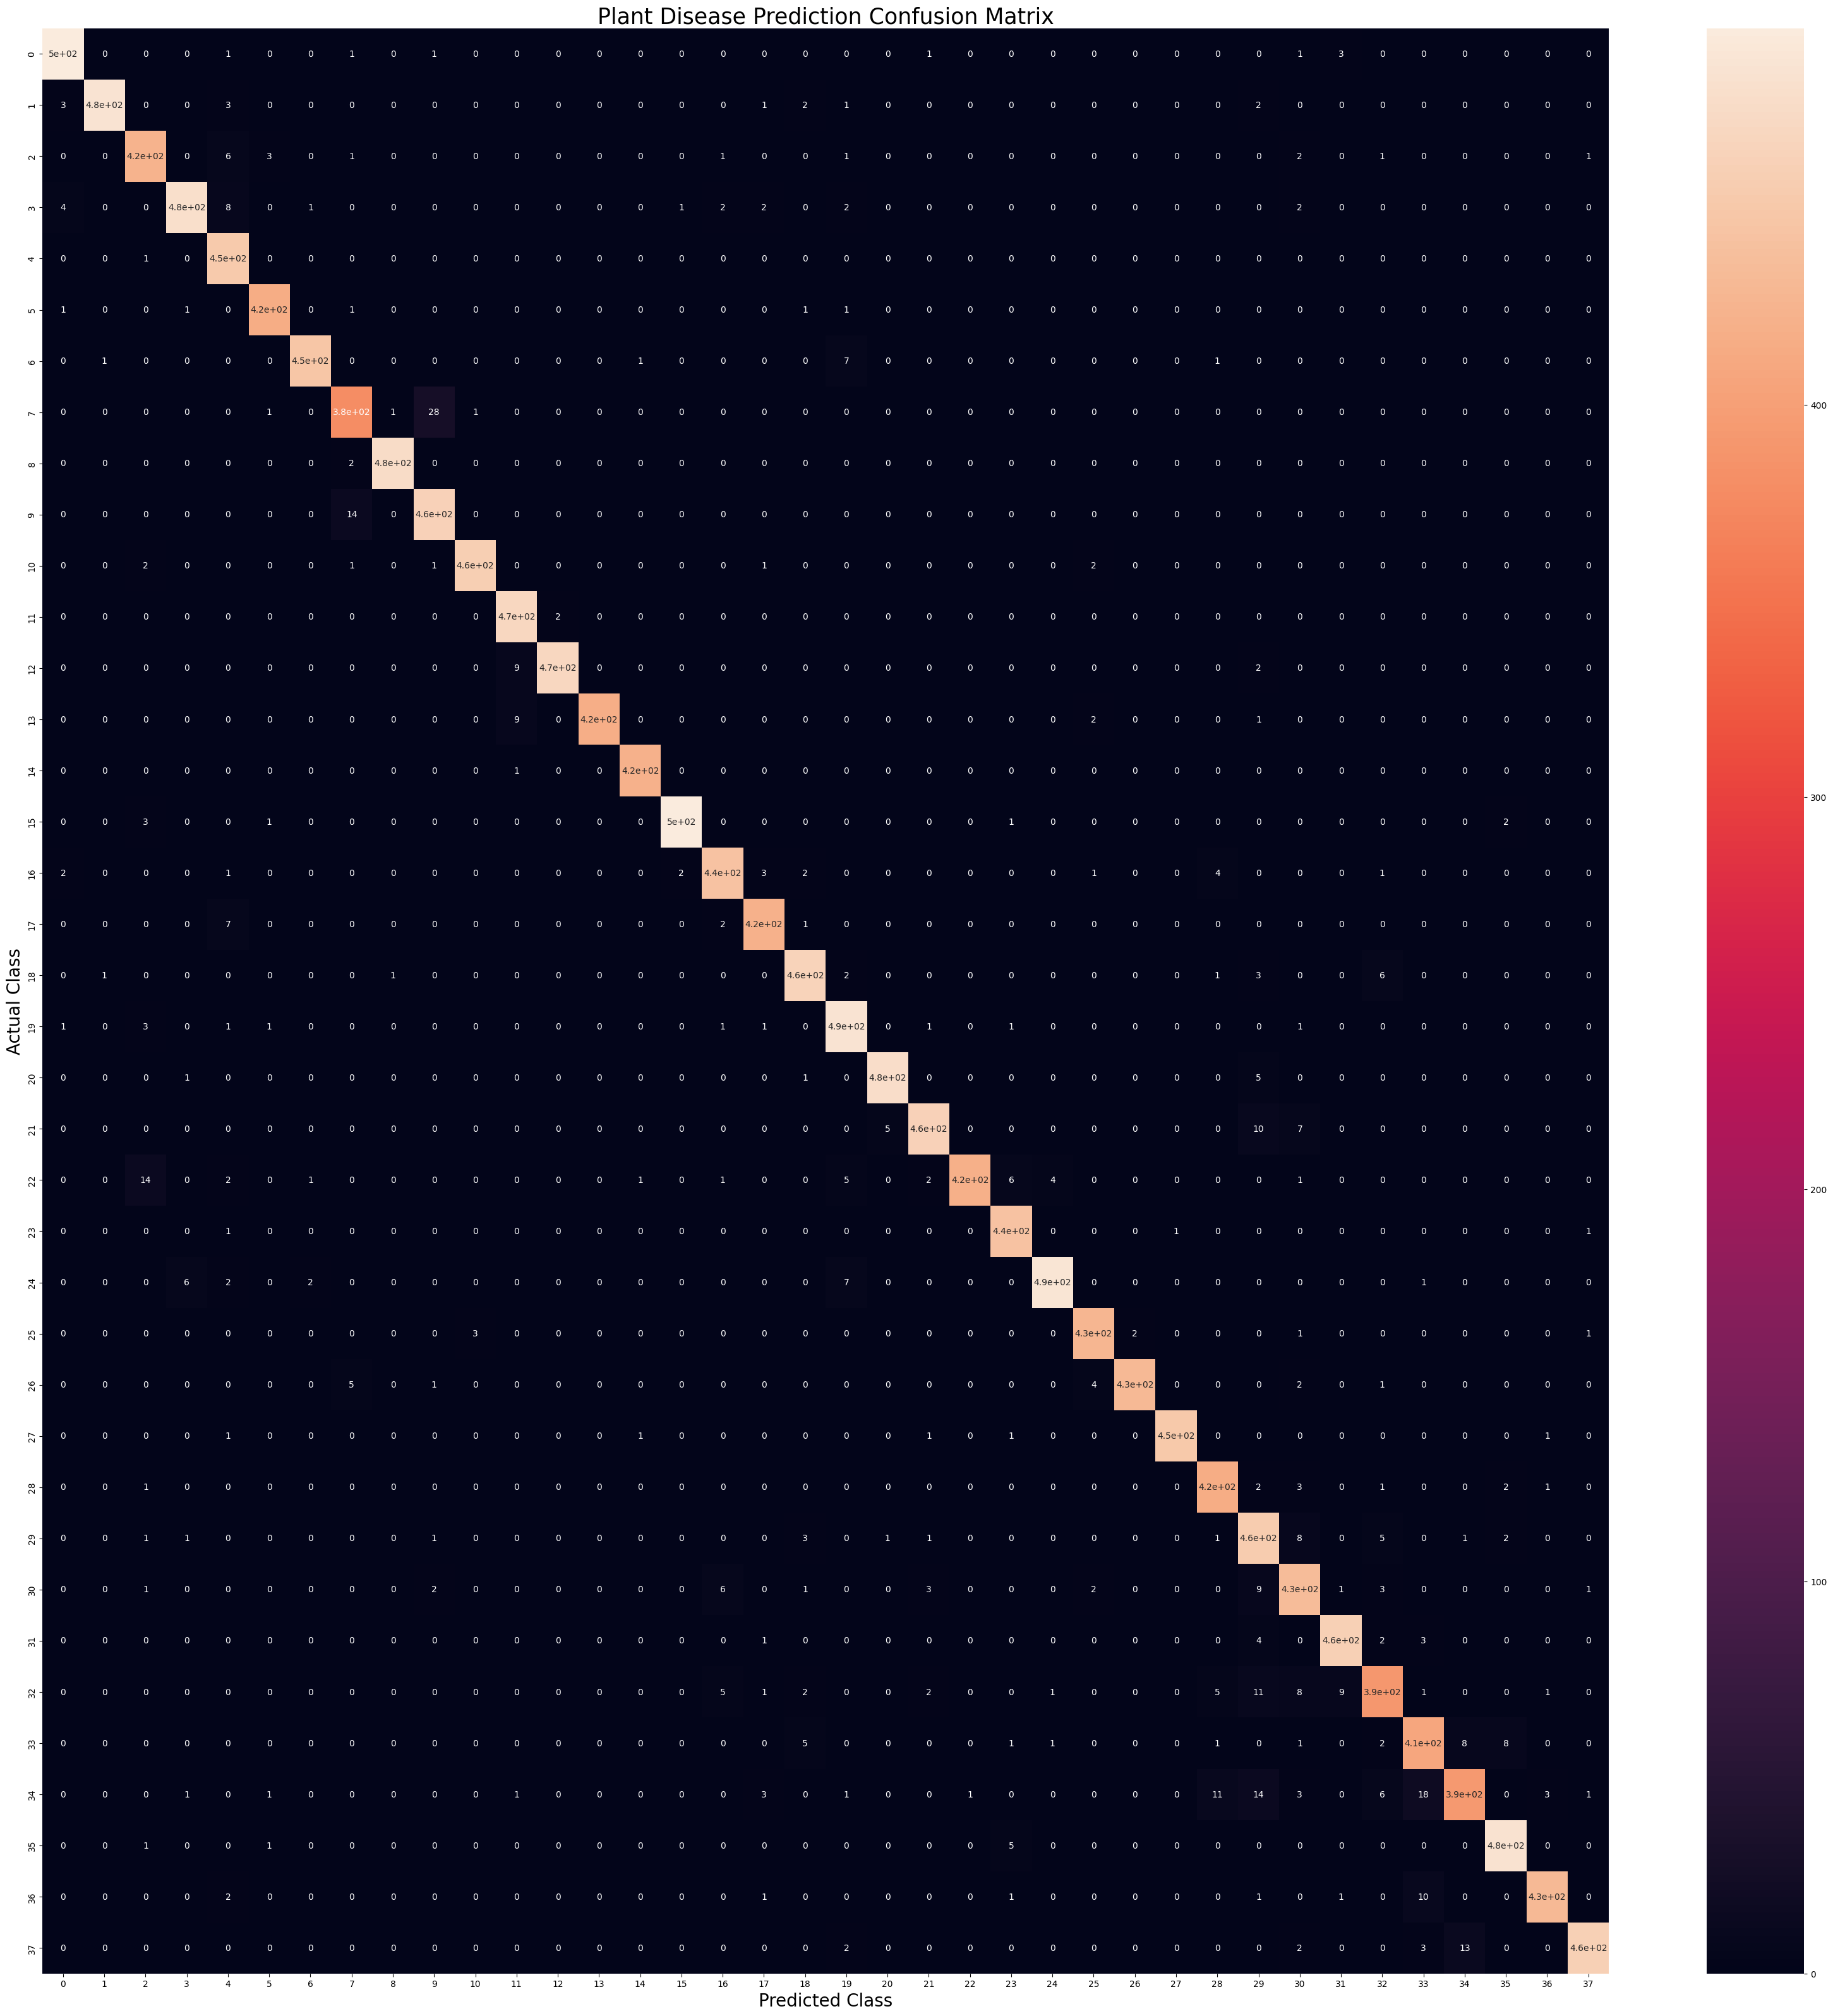

In [ ]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("Predicted Class",fontsize=20)
plt.ylabel("Actual Class",fontsize=20)
plt.title("Plant Disease Prediction Confusion Matrix",fontsize=25)
plt.show()

In [ ]:
! pip install opencv-python

   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.5 MB ? eta -:--:--
    --------------------------------------- 0.8/39.5 MB 1.5 MB/s eta 0:00:27
   - -------------------------------------- 1.0/39.5 MB 1.5 MB/s eta 0:00:26
   - -------------------------------------- 1.0/39.5 MB 1.5 MB/s eta 0:00:26
   - -------------------------------------- 1.3/39.5 MB 1.2 MB/s eta 0:00:32
   - -------------------------------------- 1.6/39.5 MB 1.2 MB/s eta 0:00:33
   - -------------------------------------- 1.8/39.5 MB 1.2 MB/s eta 0:00:31
   -- ------------------------------------- 2.1/39.5 MB 1.2 MB/s eta 0:00:31
   -- ------------------------------------- 2.4/39.5 MB 1.2 MB/s eta 0:00:30
   -- ------------------------------------- 2.4/39.5 MB 1.2 MB/s eta 0:00:30
   -- ------------------------------------- 2.4/39.5 MB 1.2 MB/s eta 0:00:30
   -- --------------

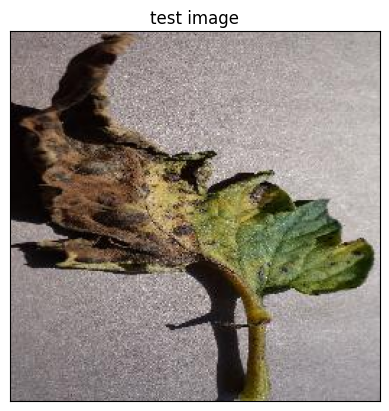

In [ ]:
import cv2
image_path = r"C:\Users\mohamed\Desktop\IA\dataset\test\test\TomatoEarlyBlight1.JPG"
# read image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#displaying image
plt.imshow(img)
plt.title("test image")
plt.xticks([])
plt.yticks([])
plt.show()


In [ ]:
import numpy as np


image = tf.keras.preprocessing.image.load_img(image_path, target_size=(128, 128))
image = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([image])  # Convert single image to a batch.
print(input_arr.shape)

(1, 128, 128, 3)


In [ ]:
prediction = model.predict(input_arr)
prediction,prediction.shape

1/1 [==============================] - 0s 223ms/step


(array([[1.14999619e-08, 1.86454017e-07, 3.96974599e-07, 7.90155408e-09,
         7.63603047e-09, 1.20238608e-09, 2.60320571e-10, 8.86506601e-09,
         8.17423296e-10, 3.54600105e-09, 9.89132734e-11, 6.20655953e-08,
         7.66356388e-05, 9.24832566e-09, 9.31379106e-12, 1.18963311e-11,
         1.43622970e-07, 1.77948838e-08, 2.28037706e-07, 1.90201654e-09,
         2.55742783e-09, 1.15107577e-08, 5.22786814e-10, 1.68368619e-09,
         1.14177064e-10, 2.85544893e-10, 1.94390941e-06, 7.22794463e-11,
         2.35984839e-06, 9.67805028e-01, 2.28365604e-02, 1.15595749e-05,
         9.21139680e-03, 8.18288441e-08, 1.91085564e-06, 2.04737489e-07,
         5.10763493e-05, 5.35143023e-08]], dtype=float32),
 (1, 38))

In [ ]:
result_index = np.argmax(prediction)
result_index


29

In [ ]:
class_name


['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

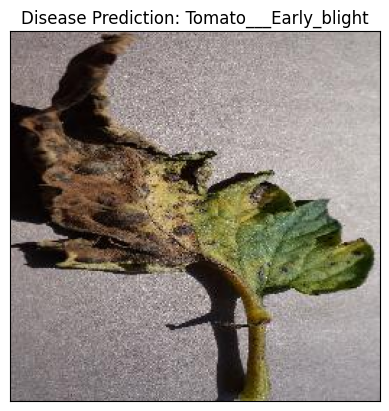

In [ ]:
# Displaying the predicted class name
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Prediction: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()
